# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [ ]:
%pip install transformers torch tqdm datasets

In [1]:
from pathlib import Path
# import os

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification

import configuration
from src import setup, data_utils, hf_utils
from src.models import bert

/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_frac = data_utils.DATA_FRACTION

# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

device = setup.setup_device_with_seeds()

batch_size = 32
learning_rate = 1e-5
num_epochs = 10
patience = 3  # early stopping, if validation loss does not improve for this many epochs

bert_base = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2  # e.g., binary sentiment
)
bert_base.config.problem_type = "single_label_classification"
# Optimizer
optimizer = AdamW(bert_base.parameters(), lr=learning_rate)

base_configs = {
    "bert": bert_base,
    "batch_size": batch_size,
    "optimizer": optimizer,
    "num_epochs": num_epochs,
    "patience": patience,
    "device": device,
}

GPU: NVIDIA A100-SXM4-80GB
Memory allocated: 0.0 GB
Memory cached: 0.0 GB
Using device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5601.94it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [3]:
def run_experiment(n_weather, n_out_topic, strategy="crossed"):
    
    df_train, df_val, df_test = data_utils.load_BERT_sets(
        n_weather=n_weather, n_out_topic=n_out_topic, strategy=strategy
    )
    
    # # ====
    # # Comment out this cell to use the full dataset. This is just for quick testing.
    # train_size = 1000
    # val_size = int(train_size * len(df_val) / len(df_train))
    # test_size = int(train_size * len(df_test) / len(df_train))

    # df_train = df_train.sample(n=train_size, random_state=setup.RANDOM_SEED)
    # df_val = df_val.sample(n=val_size, random_state=setup.RANDOM_SEED)
    # df_test = df_test.sample(n=test_size, random_state=setup.RANDOM_SEED)
    # # ----

    ds_train, ds_val, ds_test = hf_utils.create_datasets(df_train, df_val, df_test)

    # Calculate the maximum length of the tokenized tweets in the training set to set the max_length parameter for BERT
    hf_utils.max_length_dist(df_train, "tweet_text", tokenizer)
    
    ration_folder = data_utils.get_experiment_ratios_path(n_weather, n_out_topic)

    # Tokenize the datasets and save the tokenized versions.
    token_path = Path(
        f"../tokens/stage_1/{strategy}/BERT/{ration_folder}"
    )
    train_tokenized, val_tokenized, test_tokenized = hf_utils.load_or_tokenize(
        ds_train,
        ds_val,
        ds_test,
        tokenizer,
        token_path,
        force_retokenize=True,
        format_dataset=bert.format_dataset,
    )
    
    imbalance_strategy = bert.detect_imbalance_strategy(df_train["informative"])
    print(f"Detected imbalance strategy: {imbalance_strategy}")
    
    configs = {**base_configs, **imbalance_strategy}
    configs['save_path'] = f"../models/stage_1/{strategy}/BERT/{ration_folder}"

    # Fine-tune BERT
    model, train_loss_history, val_loss_history, val_f1_history, val_recall_history, val_precision_history = bert.finetune(
        train_tokenized, val_tokenized, configs
    )

    # Visualize training history
    hf_utils.plot_fine_tune_history(
        train_loss_history, val_loss_history, val_f1_history, val_recall_history, val_precision_history
    )

    predictions = bert.predict(model, test_tokenized, device)
    bert.report_metrics(test_tokenized, predictions)
    hf_utils.group_report_metrics(
        df_test, predictions, group_by="subset", labels="informative"
    )

## B. Crossed sets

Processing CROSSED sets with n_weather=2578 and n_out_topic=169652...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (552 > 512). Running this sequence through the model will result in indexing errors


90th percentile: 42.0
95th percentile: 46.0
99th percentile: 56.0
Absolute Maximum length: 552
Tokenizing datasets...


Saving the dataset (1/1 shards): 100%|██████████| 18661/18661 [00:00<00:00, 297243.67 examples/s]


Dataset Imbalance Ratio (IR): 20.00
Status: Extreme Imbalance. Using Focal Loss.
Detected imbalance strategy: {'strategy': 'focal_loss', 'minority_class_id': True, 'class_weights': tensor([ 0.5250, 10.4996]), 'use_sampler': False, 'use_focal_loss': True, 'imbalance_ratio': 19.99929666619778}
Starting BertForSequenceClassification fine-tuning...
Active Strategy: FOCAL_LOSS
--------------------------------------------------


...

Validating Epoch 4/10: 100%|██████████| 584/584 [00:22<00:00, 26.41it/s]


Epoch 4/10 | Train Loss: 0.0102 | Val Loss: 0.0319 | Val Macro F1: 0.8933 | Val Recall: 0.9682 | Val Precision: 0.8414


Validating Epoch 5/10: 100%|██████████| 584/584 [00:21<00:00, 27.37it/s]


Epoch 5/10 | Train Loss: 0.0075 | Val Loss: 0.0367 | Val Macro F1: 0.8928 | Val Recall: 0.9707 | Val Precision: 0.8394
Early stopping triggered at epoch 5. Best Val Recall: 0.9712
Loaded best model with Val Recall: 0.9712


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.16s/it]


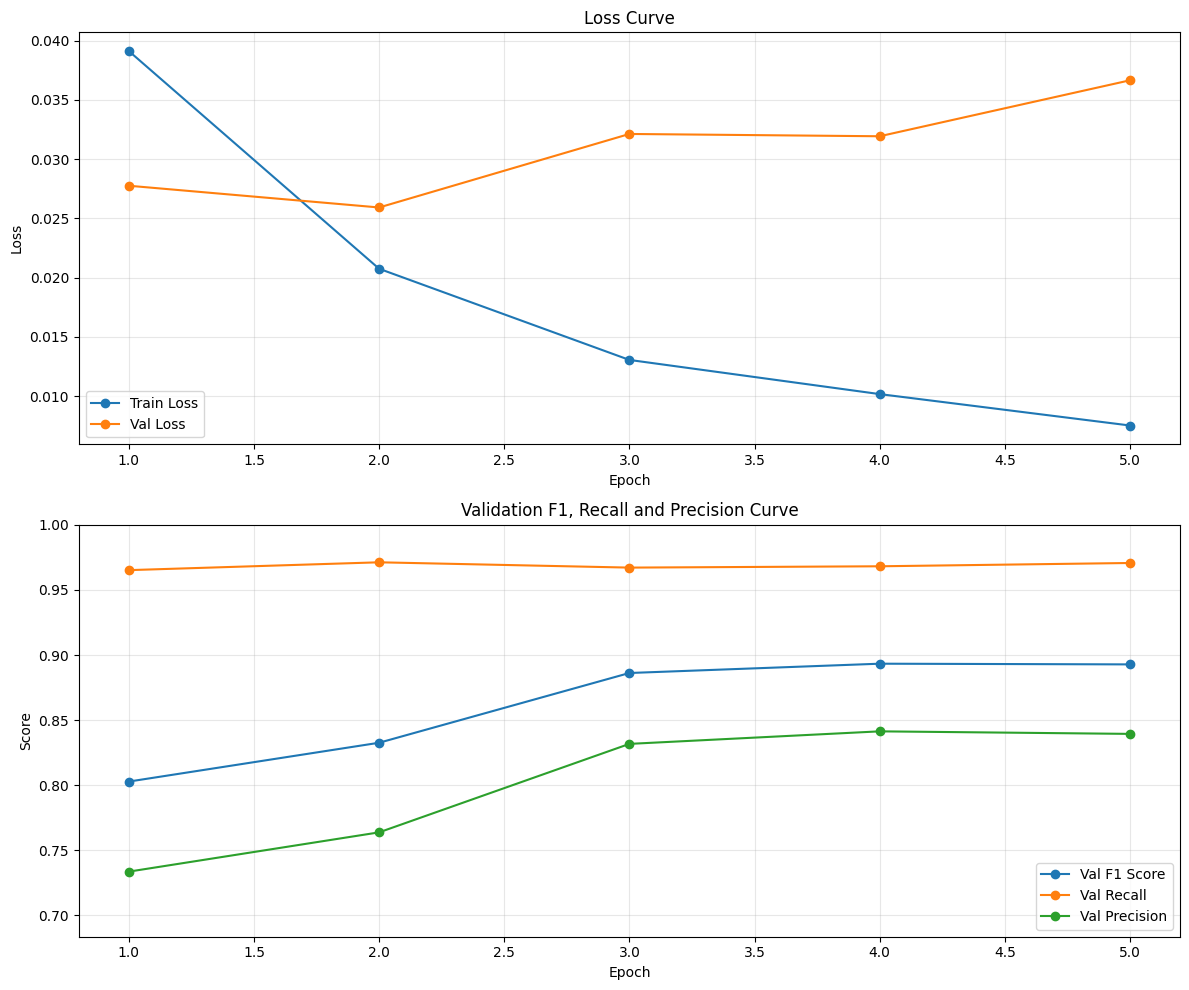

Predicting:: 100%|██████████| 1167/1167 [00:24<00:00, 47.76it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9991    0.9555    0.9768     17773
        True     0.5246    0.9831    0.6842       888

    accuracy                         0.9568     18661
   macro avg     0.7619    0.9693    0.8305     18661
weighted avg     0.9765    0.9568    0.9629     18661

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9388    0.4035    0.5644       570
        True     0.7197    0.9831    0.8310       888

    accuracy                         0.7565      1458
   macro avg     0.8292    0.6933    0.6977      1458
weighted avg     0.8053    0.7565    0.7268      1458

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9747    0.9872     16941
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_clas

In [4]:
for n_weather, n_out_topic in data_utils.BERT_CROSSED_EXPERIMENT_N:
    print(
        f"Processing CROSSED sets with n_weather={n_weather} and n_out_topic={n_out_topic}..."
    )
    run_experiment(n_weather, n_out_topic, strategy="crossed")

## C. Isolated sets

Processing ISOLATED sets with n_weather=12890 and n_out_topic=552597...
90th percentile: 42.0
95th percentile: 46.0
99th percentile: 55.0
Absolute Maximum length: 8543
Tokenizing datasets...


Saving the dataset (1/1 shards): 100%|██████████| 62506/62506 [00:00<00:00, 810873.43 examples/s]


Dataset Imbalance Ratio (IR): 19.98
Status: Extreme Imbalance. Using Focal Loss.
Detected imbalance strategy: {'strategy': 'focal_loss', 'minority_class_id': True, 'class_weights': tensor([ 0.5250, 10.4897]), 'use_sampler': False, 'use_focal_loss': True, 'imbalance_ratio': 19.97940004195511}
Starting BertForSequenceClassification fine-tuning...
Active Strategy: FOCAL_LOSS
--------------------------------------------------


Validating Epoch 1/10: 100%|██████████| 1954/1954 [01:20<00:00, 24.36it/s]


Epoch 1/10 | Train Loss: 0.0274 | Val Loss: 0.0238 | Val Macro F1: 0.8399 | Val Recall: 0.9724 | Val Precision: 0.7717


...

Validating Epoch 4/10: 100%|██████████| 1954/1954 [01:12<00:00, 27.00it/s]


Epoch 4/10 | Train Loss: 0.0098 | Val Loss: 0.0390 | Val Macro F1: 0.9265 | Val Recall: 0.9667 | Val Precision: 0.8934


Validating Epoch 5/10: 100%|██████████| 1954/1954 [01:17<00:00, 25.29it/s]


Epoch 5/10 | Train Loss: 0.0077 | Val Loss: 0.0543 | Val Macro F1: 0.9223 | Val Recall: 0.9662 | Val Precision: 0.8868
Early stopping triggered at epoch 5. Best Val Recall: 0.9745
Loaded best model with Val Recall: 0.9745


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.40s/it]


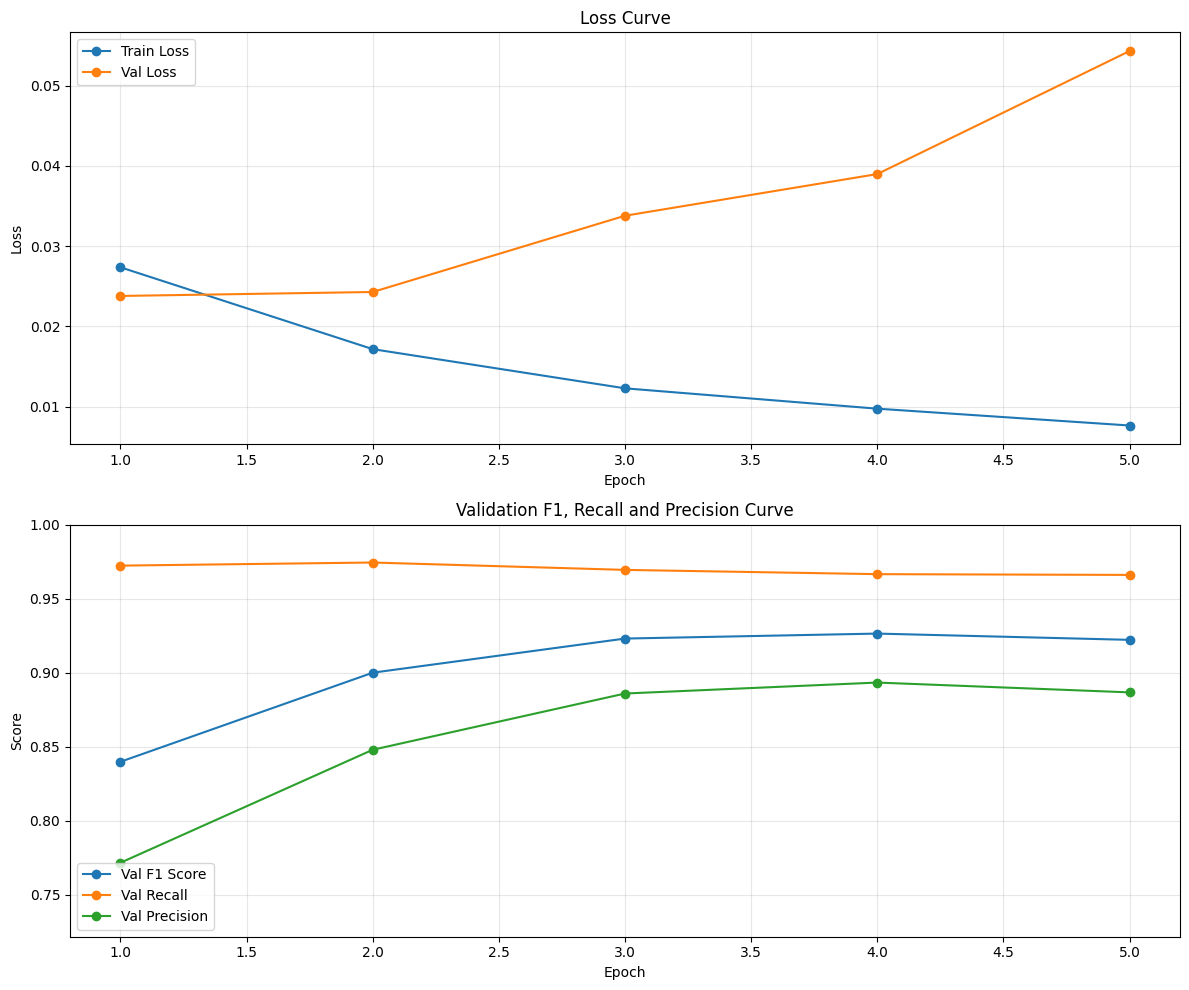

Predicting:: 100%|██████████| 3907/3907 [01:20<00:00, 48.38it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9983    0.9773    0.9877     59526
        True     0.6808    0.9661    0.7987      2980

    accuracy                         0.9768     62506
   macro avg     0.8395    0.9717    0.8932     62506
weighted avg     0.9831    0.9768    0.9787     62506

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9523    0.6740    0.7894      2991
        True     0.7470    0.9661    0.8426      2980

    accuracy                         0.8198      5971
   macro avg     0.8497    0.8201    0.8160      5971
weighted avg     0.8498    0.8198    0.8159      5971

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9937    0.9968     55301
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_clas

In [5]:
for n_weather, n_out_topic in data_utils.BERT_ISO_EXPERIMENT_N:
    print(
        f"Processing ISOLATED sets with n_weather={n_weather} and n_out_topic={n_out_topic}..."
    )
    run_experiment(n_weather, n_out_topic, strategy="isolated")